# Результаты экспериментов

Сводная таблица + графики по триаде метрик и retrieval для всех проведённых runs.

Загружает все `data/eval/results/final/metrics_triad_*.json` и строит сравнения с baseline.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
from scripts.eval_stats import bootstrap_ci, paired_bootstrap

PROJECT_ROOT = Path.cwd().parent
RESULTS_DIR = PROJECT_ROOT / 'data' / 'eval' / 'results' / 'final'
print('Results dir:', RESULTS_DIR)
print('Files:')
for f in sorted(RESULTS_DIR.glob('metrics_triad_*.json')):
    print(' ', f.name)

Results dir: /Users/yanakhalitova/workspace/project-seminar/tsu-image-description/data/eval/results/final
Files:
  metrics_triad_E-1+16_blip_large_drop_theme.json
  metrics_triad_E-16_drop_theme.json
  metrics_triad_E-1_blip_large.json
  metrics_triad_baseline.json


## 1. Загрузка результатов

In [2]:
def load_run(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

# Friendly labels per run
RUN_LABELS = {
    'metrics_triad_baseline.json':              'baseline (BLIP-base + template)',
    'metrics_triad_E-1_blip_large.json':        'E-1: BLIP-large',
    'metrics_triad_E-16_drop_theme.json':       'E-16: drop theme+mood',
    'metrics_triad_E-1+16_blip_large_drop_theme.json': 'E-1+E-16: BLIP-large + drop theme+mood',
}

runs = {}
for path in sorted(RESULTS_DIR.glob('metrics_triad_*.json')):
    label = RUN_LABELS.get(path.name, path.stem)
    runs[label] = load_run(path)

print(f'Loaded {len(runs)} runs:')
for label in runs:
    print(f'  - {label}')

Loaded 4 runs:
  - E-1+E-16: BLIP-large + drop theme+mood
  - E-16: drop theme+mood
  - E-1: BLIP-large
  - baseline (BLIP-base + template)


## 2. Сводная таблица метрик

In [3]:
def summarize_run(run):
    s = run['summary']
    return {
        'n':                       s['num_examples'],
        'CLIPScore_RU(archive)':   s['metrics']['CLIPScore_RU_archive_ru'],
        'CLIPScore_RU(caption_ru)': s['metrics']['CLIPScore_RU_caption_ru'],
        'CLIPScore_EN(caption_en)': s['metrics']['CLIPScore_EN_caption_en'],
        'R@1 i2t':                 s['retrieval']['i2t']['R@1'],
        'R@5 i2t':                 s['retrieval']['i2t']['R@5'],
        'R@1 t2i':                 s['retrieval']['t2i']['R@1'],
        'R@5 t2i':                 s['retrieval']['t2i']['R@5'],
        'mean_rank_t2i':           s['retrieval']['mean_rank_t2i'],
        'Latency sec/img':         s['latency']['mean_sec'],
    }

table = pd.DataFrame({label: summarize_run(r) for label, r in runs.items()}).T
table.index.name = 'run'
table.round(4)

,n,CLIPScore_RU(archive),CLIPScore_RU(caption_ru),CLIPScore_EN(caption_en),R@1 i2t,R@5 i2t,R@1 t2i,R@5 t2i,mean_rank_t2i,Latency sec/img
run,,,,,,,,,,
E-1+E-16: BLIP-large + drop theme+mood,20.0,0.3341,0.3077,0.2941,0.90,0.95,0.90,0.95,1.50,0.9842
E-16: drop theme+mood,20.0,0.3262,0.3012,0.2983,0.80,0.95,0.75,0.95,2.00,0.7449
E-1: BLIP-large,20.0,0.3313,0.3077,0.2941,0.90,1.00,0.80,0.95,1.75,1.0038
baseline (BLIP-base + template),20.0,0.3254,0.3012,0.2983,0.75,1.00,0.70,0.90,2.40,0.7114


## 3. Bootstrap CI для каждого run

In [4]:
def per_item_values(run, key='CLIPScore_RU_archive_ru'):
    return [it['scores'][key] for it in run['per_item'] if it['scores'].get(key) is not None]

ci_rows = []
for label, run in runs.items():
    values = per_item_values(run)
    mean = float(np.mean(values))
    ci_lo, ci_hi = bootstrap_ci(values, n_iter=1000, conf=0.95, seed=42)
    ci_rows.append({
        'run':    label,
        'mean':   mean,
        'ci_lo':  ci_lo,
        'ci_hi':  ci_hi,
        'err':    (ci_hi - ci_lo) / 2,
    })

ci_df = pd.DataFrame(ci_rows)
ci_df.round(4)

,run,mean,ci_lo,ci_hi,err
0,E-1+E-16: BLIP-large + drop theme+mood,0.3341,0.3166,0.3507,0.0170
1,E-16: drop theme+mood,0.3262,0.3089,0.3437,0.0174
2,E-1: BLIP-large,0.3313,0.3136,0.3487,0.0175
3,baseline (BLIP-base + template),0.3254,0.3107,0.3406,0.0150


## 4. Bar chart: CLIPScore_RU(archive) ± CI95

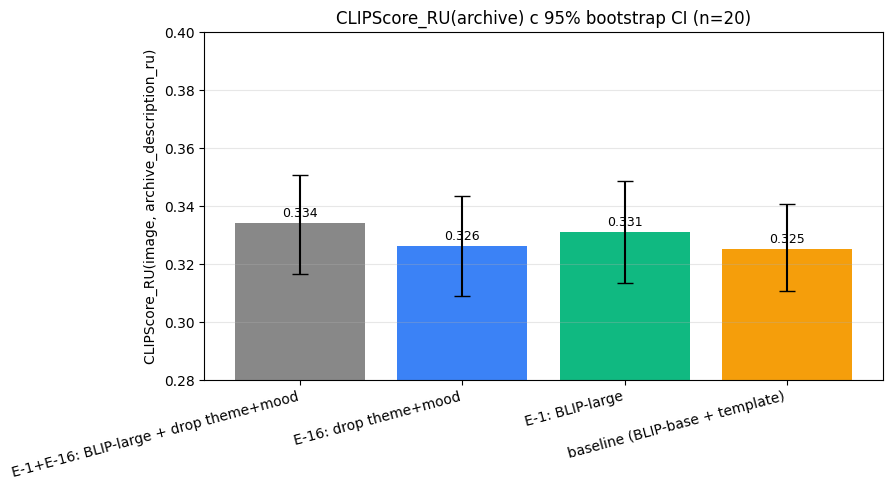

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(ci_df))
ax.bar(x, ci_df['mean'], yerr=[ci_df['mean'] - ci_df['ci_lo'], ci_df['ci_hi'] - ci_df['mean']],
       capsize=6, color=['#888', '#3b82f6', '#10b981', '#f59e0b'][:len(ci_df)])

ax.set_xticks(x)
ax.set_xticklabels(ci_df['run'], rotation=15, ha='right')
ax.set_ylabel('CLIPScore_RU(image, archive_description_ru)')
ax.set_title('CLIPScore_RU(archive) с 95% bootstrap CI (n=20)')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.28, 0.40)

for i, row in ci_df.iterrows():
    ax.text(i, row['mean'] + 0.002, f"{row['mean']:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'plots' / 'clipscore_ru_archive_with_ci.png', dpi=150, bbox_inches='tight') if (RESULTS_DIR / 'plots').exists() else None
plt.show()

## 5. Retrieval R@k (t2i — основное направление для архивного поиска)

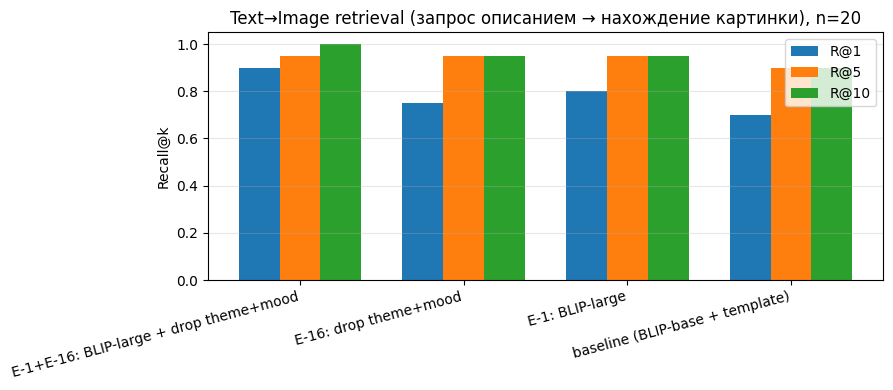

In [6]:
retrieval_rows = []
for label, run in runs.items():
    s = run['summary']['retrieval']
    retrieval_rows.append({
        'run':    label,
        'R@1':    s['t2i']['R@1'],
        'R@5':    s['t2i']['R@5'],
        'R@10':   s['t2i'].get('R@10', s['t2i']['R@5']),
    })
ret_df = pd.DataFrame(retrieval_rows)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(ret_df))
width = 0.25
ax.bar(x - width, ret_df['R@1'], width, label='R@1')
ax.bar(x,         ret_df['R@5'], width, label='R@5')
ax.bar(x + width, ret_df['R@10'], width, label='R@10')
ax.set_xticks(x)
ax.set_xticklabels(ret_df['run'], rotation=15, ha='right')
ax.set_ylabel('Recall@k')
ax.set_title('Text→Image retrieval (запрос описанием → нахождение картинки), n=20')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 6. Paired bootstrap p-value vs baseline

In [7]:
baseline_label = [l for l in runs if 'baseline' in l.lower()][0]
baseline_values = per_item_values(runs[baseline_label])

p_rows = []
for label, run in runs.items():
    if label == baseline_label:
        continue
    cand_values = per_item_values(run)
    delta = float(np.mean(cand_values) - np.mean(baseline_values))
    p = paired_bootstrap(baseline_values, cand_values, n_iter=1000, seed=42)
    p_rows.append({
        'run':    label,
        'delta_mean': delta,
        'p_value':    p,
        'significant @ 0.1': 'yes' if p < 0.1 else 'no',
    })

pd.DataFrame(p_rows).round(4)

,run,delta_mean,p_value,significant @ 0.1
0,E-1+E-16: BLIP-large + drop theme+mood,0.0087,0.245,no
1,E-16: drop theme+mood,0.0008,0.884,no
2,E-1: BLIP-large,0.0059,0.369,no


## 7. Per-image сравнение (heatmap: run × image)

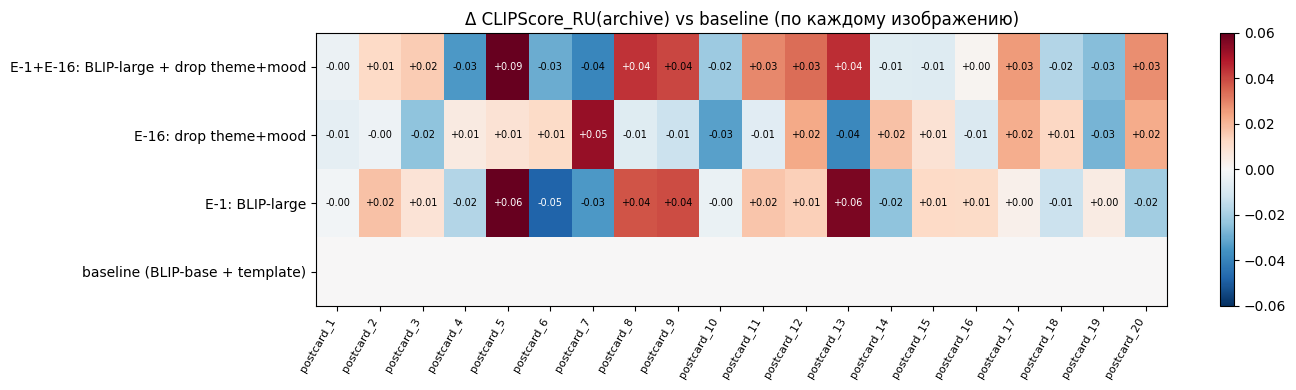

In [8]:
per_image = {}
for label, run in runs.items():
    per_image[label] = [it['scores']['CLIPScore_RU_archive_ru'] for it in run['per_item']]

image_names = [Path(it['image_path']).stem for it in runs[baseline_label]['per_item']]
M = np.array([per_image[l] for l in runs])

# Render delta vs baseline
deltas = M - M[list(runs).index(baseline_label)]

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(deltas, aspect='auto', cmap='RdBu_r', vmin=-0.06, vmax=0.06)
ax.set_yticks(np.arange(len(runs)))
ax.set_yticklabels(list(runs))
ax.set_xticks(np.arange(len(image_names)))
ax.set_xticklabels(image_names, rotation=60, ha='right', fontsize=8)
for i in range(len(runs)):
    for j in range(len(image_names)):
        if abs(deltas[i, j]) > 0.001:
            ax.text(j, i, f'{deltas[i, j]:+.02f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(deltas[i, j]) > 0.04 else 'black')
ax.set_title('Δ CLIPScore_RU(archive) vs baseline (по каждому изображению)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 8. Качественный анализ — примеры описаний

In [9]:
# Show first 5 examples across all runs
for i in range(5):
    print(f"--- {image_names[i]} ---")
    print(f"  reference: {runs[baseline_label]['per_item'][i]['reference_ru']}")
    for label, run in runs.items():
        it = run['per_item'][i]
        score = it['scores']['CLIPScore_RU_archive_ru']
        print(f"  [{score:.3f}] {label}:")
        print(f"          {it['archive_ru']}")
    print()

--- postcard_1 ---
  reference: Сосновый лес
  [0.322] E-1+E-16: BLIP-large + drop theme+mood:
          Фотография в стиле черно-белая фотография. На изображении: Есть черно-белая фотография леса с деревьями..
  [0.320] E-16: drop theme+mood:
          Фотография в стиле черно-белая фотография. На изображении: черно-белое фото деревьев в лесу.
  [0.324] E-1: BLIP-large:
          Фотография в стиле черно-белая фотография. На изображении: Есть черно-белая фотография леса с деревьями.. Предположительно, это сцена природы. Общее настроение изображения можно охарактеризовать как ностальгическое.
  [0.326] baseline (BLIP-base + template):
          Фотография в стиле черно-белая фотография. На изображении: черно-белое фото деревьев в лесу. Предположительно, это сцена природы. Общее настроение изображения можно охарактеризовать как ностальгическое.

--- postcard_2 ---
  reference: Зима в лесу. Картины деревенской жизни России.
  [0.344] E-1+E-16: BLIP-large + drop theme+mood:
          Фото